In [1]:
import pandas as pd
import numpy as np

In [5]:
df_full = pd.read_csv('car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [6]:
cols = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']
df = df_full[cols].copy()

In [7]:
df.isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [9]:
for col in df.columns:
    if df[col].isna().sum() > 0:
        print(f'The column with missing values is {col}')
    else:
        continue

The column with missing values is horsepower


In [13]:
median = df.horsepower.median()
print(f"The median for the variable 'horsepower' is {median}")

The median for the variable 'horsepower' is 149.0


PREPARING THE DATASET

Dataset shape: (9704, 5)

First few rows:
   engine_displacement  horsepower  vehicle_weight  model_year  \
0                  170       159.0     3413.433759        2003   
1                  130        97.0     3149.664934        2007   
2                  170        78.0     3079.038997        2018   
3                  220         NaN     2542.392402        2009   
4                  210       140.0     3460.870990        2009   

   fuel_efficiency_mpg  
0            13.231729  
1            13.688217  
2            14.246341  
3            16.912736  
4            12.488369  

EDA - Fuel Efficiency Distribution

Fuel efficiency statistics:
count    9704.000000
mean       14.985243
std         2.556468
min         6.200971
25%        13.267459
50%        15.006037
75%        16.707965
max        25.967222
Name: fuel_efficiency_mpg, dtype: float64

Plot saved as 'fuel_efficiency_distribution.png'
Does it have a long tail? Check the plot to see if distribution

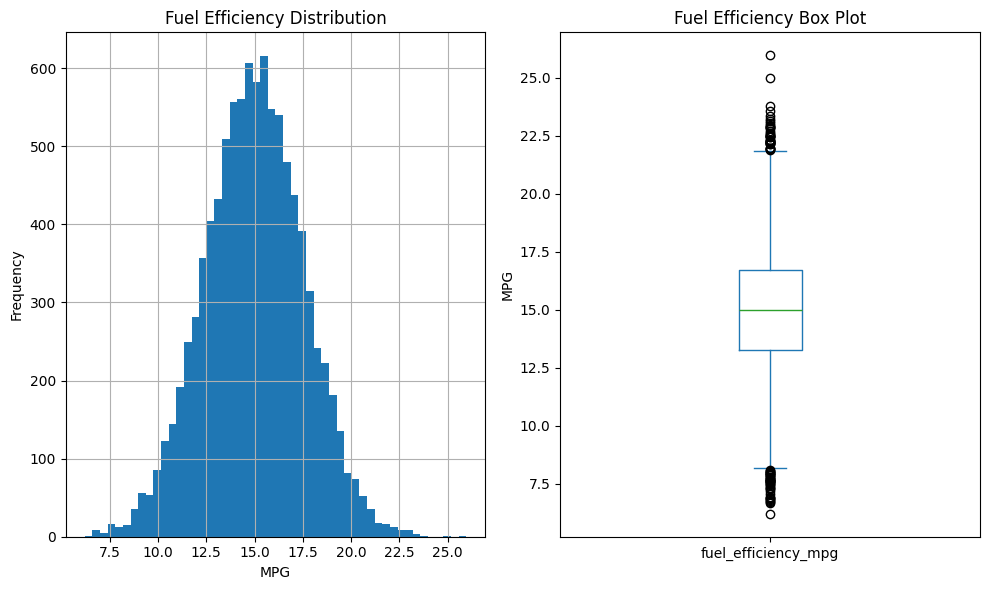

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the CSV file
df = pd.read_csv('car_fuel_efficiency.csv')

print("="*70)
print("PREPARING THE DATASET")
print("="*70)

# Use only specified columns
columns_to_use = ['engine_displacement', 'horsepower', 'vehicle_weight', 
                  'model_year', 'fuel_efficiency_mpg']
df = df[columns_to_use]

print(f"\nDataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# EDA
print("\n" + "="*70)
print("EDA - Fuel Efficiency Distribution")
print("="*70)
print("\nFuel efficiency statistics:")
print(df['fuel_efficiency_mpg'].describe())

# Check for long tail
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
df['fuel_efficiency_mpg'].hist(bins=50)
plt.title('Fuel Efficiency Distribution')
plt.xlabel('MPG')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df['fuel_efficiency_mpg'].plot(kind='box')
plt.title('Fuel Efficiency Box Plot')
plt.ylabel('MPG')
plt.tight_layout()
plt.savefig('fuel_efficiency_distribution.png')
print("\nPlot saved as 'fuel_efficiency_distribution.png'")
print("Does it have a long tail? Check the plot to see if distribution is skewed.")

# Question 1
print("\n" + "="*70)
print("QUESTION 1: Column with Missing Values")
print("="*70)
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values)
print(f"\nColumn with missing values: {missing_values[missing_values > 0].index[0]}")

# Question 2
print("\n" + "="*70)
print("QUESTION 2: Median Horsepower")
print("="*70)
median_hp = df['horsepower'].median()
print(f"\nMedian horsepower: {median_hp}")

# Prepare and split the dataset
print("\n" + "="*70)
print("PREPARING AND SPLITTING THE DATASET")
print("="*70)

# Shuffle with seed 42
np.random.seed(42)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split 60/20/20
n = len(df_shuffled)
n_train = int(0.6 * n)
n_val = int(0.2 * n)

df_train = df_shuffled[:n_train].copy()
df_val = df_shuffled[n_train:n_train+n_val].copy()
df_test = df_shuffled[n_train+n_val:].copy()

print(f"\nTrain set: {len(df_train)} rows")
print(f"Validation set: {len(df_val)} rows")
print(f"Test set: {len(df_test)} rows")

# Prepare features and target
def prepare_X_y(df):
    df_full = df.copy()
    y = df_full['fuel_efficiency_mpg'].values
    del df_full['fuel_efficiency_mpg']
    X = df_full.values
    return X, y

# Linear regression functions
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    reg[0, 0] = 0
    XTX = XTX + reg
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def rmse(y_true, y_pred):
    se = (y_true - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

# Question 3
print("\n" + "="*70)
print("QUESTION 3: Filling Missing Values (0 vs Mean)")
print("="*70)

# Option 1: Fill with 0
df_train_0 = df_train.fillna(0)
df_val_0 = df_val.fillna(0)

X_train_0, y_train = prepare_X_y(df_train_0)
X_val_0, y_val = prepare_X_y(df_val_0)

w0_0, w_0 = train_linear_regression(X_train_0, y_train)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse_0 = rmse(y_val, y_pred_0)

print(f"\nOption 1 - Fill with 0:")
print(f"RMSE: {round(rmse_0, 2)}")

# Option 2: Fill with mean (using training data only)
missing_col = df_train.columns[df_train.isnull().any()][0]
mean_value = df_train[missing_col].mean()

df_train_mean = df_train.fillna(mean_value)
df_val_mean = df_val.fillna(mean_value)

X_train_mean, y_train = prepare_X_y(df_train_mean)
X_val_mean, y_val = prepare_X_y(df_val_mean)

w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_mean = rmse(y_val, y_pred_mean)

print(f"\nOption 2 - Fill with mean ({mean_value:.2f}):")
print(f"RMSE: {round(rmse_mean, 2)}")

print(f"\nBetter option: {'With 0' if rmse_0 < rmse_mean else 'With mean' if rmse_mean < rmse_0 else 'Both are equally good'}")

# Question 4
print("\n" + "="*70)
print("QUESTION 4: Regularized Linear Regression")
print("="*70)

r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    w0, w = train_linear_regression_reg(X_train_0, y_train, r=r)
    y_pred = w0 + X_val_0.dot(w)
    score = rmse(y_val, y_pred)
    rmse_scores[r] = round(score, 2)
    print(f"r = {r:6.2f}: RMSE = {round(score, 2)}")

best_r = min(rmse_scores, key=rmse_scores.get)
print(f"\nBest r value: {best_r}")

# Question 5
print("\n" + "="*70)
print("QUESTION 5: Standard Deviation Across Different Seeds")
print("="*70)

seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
seed_scores = []

for seed in seeds:
    # Shuffle with different seed
    df_shuffled_seed = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # Split
    df_train_seed = df_shuffled_seed[:n_train].copy()
    df_val_seed = df_shuffled_seed[n_train:n_train+n_val].copy()
    
    # Fill with 0
    df_train_seed = df_train_seed.fillna(0)
    df_val_seed = df_val_seed.fillna(0)
    
    # Prepare data
    X_train_seed, y_train_seed = prepare_X_y(df_train_seed)
    X_val_seed, y_val_seed = prepare_X_y(df_val_seed)
    
    # Train without regularization
    w0, w = train_linear_regression(X_train_seed, y_train_seed)
    y_pred = w0 + X_val_seed.dot(w)
    score = rmse(y_val_seed, y_pred)
    seed_scores.append(score)
    print(f"Seed {seed}: RMSE = {round(score, 2)}")

std_scores = np.std(seed_scores)
print(f"\nStandard deviation of scores: {round(std_scores, 3)}")

# Question 6
print("\n" + "="*70)
print("QUESTION 6: Final Test with Seed 9 and r=0.001")
print("="*70)

# Split with seed 9
df_shuffled_9 = df.sample(frac=1, random_state=9).reset_index(drop=True)

df_train_9 = df_shuffled_9[:n_train].copy()
df_val_9 = df_shuffled_9[n_train:n_train+n_val].copy()
df_test_9 = df_shuffled_9[n_train+n_val:].copy()

# Combine train and validation
df_full_train = pd.concat([df_train_9, df_val_9]).reset_index(drop=True)

# Fill with 0
df_full_train = df_full_train.fillna(0)
df_test_9 = df_test_9.fillna(0)

# Prepare data
X_full_train, y_full_train = prepare_X_y(df_full_train)
X_test, y_test = prepare_X_y(df_test_9)

# Train with r=0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
y_pred_test = w0 + X_test.dot(w)
rmse_test = rmse(y_test, y_pred_test)

print(f"\nRMSE on test dataset: {round(rmse_test, 2)}")

print("\n" + "="*70)
print("SUMMARY OF ANSWERS")
print("="*70)
print(f"Q1: Column with missing values - {missing_col}")
print(f"Q2: Median horsepower - {median_hp}")
print(f"Q3: Better option - {'With 0' if rmse_0 < rmse_mean else 'With mean' if rmse_mean < rmse_0 else 'Both are equally good'}")
print(f"Q4: Best r value - {best_r}")
print(f"Q5: Standard deviation - {round(std_scores, 3)}")
print(f"Q6: Test RMSE - {round(rmse_test, 2)}")